# dPCA with EMA

In [2]:
import numpy as np

def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

sessions=load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

s0 = sessions[0]

## Correcting time

In [3]:
# --- CORRECTION OF TIMING ---
# Shift timing so that t=0 is one timepoint earlier
time_axis = s0['filter_ps_time']
dt = time_axis[1] - time_axis[0]
print(f"Original Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")

# The user wants the current index for 0 to now be +dt (or rather, the index -1 is the new 0).
# If correct t=0 is one timepoint BEFORE current t=0:
# Current: ... t[-1]=-dt, t[0]=0, t[1]=dt ...
# New:     ... t[-1]=0,   t[0]=dt, ... (This shifts time array to the right? No.)

# "stimulus onset 1 timepoint before before what is currently indicated"
# Current 0 is at index `zero_idx`.
# We want index `zero_idx - 1` to be the new 0.
# So we need to ADD `dt` to the time axis? 
# If t[zero_idx] = 0, and we want t[zero_idx-1] = 0.
# Currently t[zero_idx-1] = -dt. 
# To make it 0, we add dt. 
# Then t[zero_idx] becomes dt.

s0['filter_ps_time'] = s0['filter_ps_time'] + dt
time_axis = s0['filter_ps_time']
zero_idx = np.argmin(np.abs(time_axis))

print(f"Corrected Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")
print(f"New Stimulus Onset Index: {zero_idx}, Time: {time_axis[zero_idx]:.4f}s")

Original Time Range: -7.9667 to 6.0000
Corrected Time Range: -7.9333 to 6.0333
New Stimulus Onset Index: 238, Time: -0.0000s


### Perform dPCA

In [4]:
import time
import builtins # Force built-in min
from dPCA import dPCA
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.patches as mpatches

# --- 1. Data Preparation (Standard 80/20 Split) ---
start_time = time.time()

# Extract data
neural_data = s0['behaviour_trials']  # (N, n_trials, T)
trial_subsets = s0['trial_subsets']   # Magnitude of stim per trial
n_trials = s0['n_trials']

# Standard random 80/20 split
all_indices = np.arange(n_trials)
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")
print(f"Training trial index range: [{train_indices.min()}, {train_indices.max()}]")

# Prepare dPCA data strictly from TRAINING trials only
unique_conditions = np.unique(trial_subsets)
trials_per_cond_train = {
    cond: np.intersect1d(np.where(trial_subsets == cond)[0], train_indices)
    for cond in unique_conditions
}

# Balanced trial count required by dPCA trial tensor shape (trials, N, S, T)
min_trials_train = builtins.min([len(t) for t in trials_per_cond_train.values()])

N, T = s0['n_cells'], s0['n_times']
S = len(unique_conditions)

# Construct trialR for dPCA (min_trials_train, N, S, T)
# Use random sampling from each training-condition pool to avoid biasing to earliest indices
rng = np.random.default_rng(42)
trialR = np.zeros((min_trials_train, N, S, T))
for s, cond in enumerate(unique_conditions):
    pool = trials_per_cond_train[cond]
    selected_trials = rng.choice(pool, size=min_trials_train, replace=False)
    for i, t_idx in enumerate(selected_trials):
        trialR[i, :, s, :] = neural_data[:, t_idx, :]

# Averaged R (N, S, T), centered from training-only trialR
R = np.mean(trialR, axis=0)
R_centered = R - np.mean(R.reshape((N, -1)), axis=1)[:, None, None]

print(f"dPCA Data Prepared from TRAIN ONLY. Shape: {trialR.shape}")
print(f"Balanced trials per condition used for dPCA fit: {min_trials_train}")
print(f"Preparation time: {time.time() - start_time:.4f}s")

Data Split: 129 Training trials, 33 Test trials
Training trial index range: [0, 161]
dPCA Data Prepared from TRAIN ONLY. Shape: (6, 471, 8, 420)
Balanced trials per condition used for dPCA fit: 6
Preparation time: 0.0254s


In [17]:
import pandas as pd

t0 = time.time()

dpca = dPCA.dPCA(labels='st', regularizer='auto', n_components=10)
dpca.protect = ['t']
Z = dpca.fit_transform(R_centered, trialR)

# Apply Exponential Moving Average (EMA) smoothing to all dPCA data (Z)
alpha = 0.5 # Adjust this value for more or less smoothing (0 < alpha <= 1)

Z_smoothed = {}
for k, v in Z.items():
    # v has shape (n_components, n_stimuli, n_timepoints)
    n_comp, n_stim, n_time = v.shape
    
    # Reshape to (n_timepoints, n_components * n_stimuli) for pandas
    v_reshaped = v.reshape(n_comp * n_stim, n_time).T
    
    # Apply EMA
    v_smoothed = pd.DataFrame(v_reshaped).ewm(alpha=alpha, adjust=False).mean().values
    
    # Reshape back to (n_components, n_stimuli, n_timepoints)
    Z_smoothed[k] = v_smoothed.T.reshape(n_comp, n_stim, n_time)

# Replace Z with Z_smoothed so further plots use the smoothed data
Z = Z_smoothed

print(f"dPCA Fitting and EMA smoothing time: {time.time() - t0:.4f}s")

You chose to determine the regularization parameter automatically. This can
                    take substantial time and grows linearly with the number of crossvalidation
                    folds. The latter can be set by changing self.n_trials (default = 3). Similarly,
                    use self.protect to set the list of axes that are not supposed to get to get shuffled
                    (e.g. upon splitting the data into test- and training, time-points should always
                    be drawn from the same trial, i.e. self.protect = ['t']). This can significantly
                    speed up the code.
Start optimizing regularization.
Starting trial  1 / 3
Starting trial  2 / 3
Starting trial  3 / 3
Optimized regularization, optimal lambda =  0.0008819763977946266
Regularization will be fixed; to compute the optimal                    parameter again on the next fit, please                    set opt_regularizer_flag to True.
dPCA Fitting and EMA smoothing time: 9.9171s


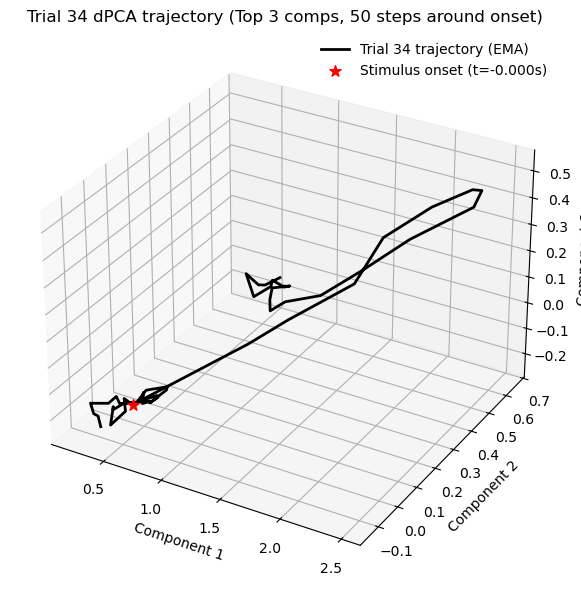

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

trial_id = 34
alpha = 0.3  # EMA smoothing factor
window_size = 50
half_window = window_size // 2

# Extract and center one trial exactly like the dPCA fit centering
trial_data = neural_data[:, trial_id, :]  # (N, T)
mean_N = np.mean(R.reshape((N, -1)), axis=1)
trial_data_centered = trial_data - mean_N[:, None]

# Project trial into dPCA space
z_trial_dict = dpca.transform(trial_data_centered)

# Combine available marginals and keep top 3 components
components = []
for key in ['t', 'st', 's']:
    if key in z_trial_dict:
        arr = np.asarray(z_trial_dict[key]).squeeze()
        if arr.ndim == 1:
            arr = arr[None, :]
        if arr.shape[0] == trial_data_centered.shape[1] and arr.shape[1] != trial_data_centered.shape[1]:
            arr = arr.T
        components.append(arr)

if len(components) == 0:
    raise ValueError("No dPCA marginals found in transformed trial output.")

z_trial = np.concatenate(components, axis=0)[:3, :].T  # (T, 3)

# Smooth trajectory with EMA over time
z_trial_smoothed = pd.DataFrame(z_trial).ewm(alpha=alpha, adjust=False).mean().values

# Keep only 50 time steps around stimulus onset
start_idx = max(0, zero_idx - half_window)
end_idx = min(z_trial_smoothed.shape[0], zero_idx + half_window)
z_window = z_trial_smoothed[start_idx:end_idx]
onset_in_window = zero_idx - start_idx

# Plot 3D trajectory and mark stimulus onset
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(
    z_window[:, 0],
    z_window[:, 1],
    z_window[:, 2],
    color='black',
    lw=2,
    label='Trial 34 trajectory (EMA)',
)

ax.scatter(
    z_window[onset_in_window, 0],
    z_window[onset_in_window, 1],
    z_window[onset_in_window, 2],
    color='red',
    s=70,
    marker='*',
    label=f'Stimulus onset (t={time_axis[zero_idx]:.3f}s)',
)

ax.set_title(f'Trial 34 dPCA trajectory (Top 3 comps, {end_idx - start_idx} steps around onset)')
ax.set_xlabel('Component 1')
ax.set_ylabel('Component 2')
ax.set_zlabel('Component 3')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()